# Studi Kasus 1: Prediksi Tingkat Stres Mahasiswa (Supervised Learning)

Tugas akhir mata kuliah Fundamental Sains Data (TriVerse). Studi kasus ini memprediksi tingkat stres mahasiswa (`stress_level`: 0 = Rendah, 1 = Sedang, 2 = Tinggi) menggunakan 20 fitur numerik (psikologis, fisiologis, lingkungan, akademik, dan sosial).

Dataset: Kaggle `rxnach/student-stress-factors-a-comprehensive-analysis`.

**Catatan etis:** hasil model ini adalah self-assessment edukatif untuk membantu mahasiswa mengenali indikasi/estimasi tingkat stres, bukan diagnosis klinis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
data_path = os.path.join("..", "data", "StressLevelDataset.csv")
df = pd.read_csv(data_path)
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,3,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,2,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,3,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,2,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,4,3,4,3,1,2,1,5,0,5,1


## 1. Pemahaman Dataset

In [3]:
print("Jumlah baris, kolom:", df.shape)
df.info()

Jumlah baris, kolom: (1100, 21)
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load  

Dataset berisi 1.100 baris dan 21 kolom: 20 fitur numerik ordinal/diskrit (kategori psikologis, fisiologis, lingkungan, akademik, sosial) dan 1 kolom target `stress_level`. Semua kolom bertipe numerik sehingga tidak diperlukan encoding kategorikal.

In [4]:
print("Label unik stress_level:", sorted(df["stress_level"].unique()))
df["stress_level"].value_counts().sort_index()

Label unik stress_level: [np.int64(0), np.int64(1), np.int64(2)]


stress_level
0    373
1    358
2    369
Name: count, dtype: int64

Target `stress_level` memiliki 3 kelas (0 = Rendah, 1 = Sedang, 2 = Tinggi) dengan distribusi yang cukup seimbang (373 / 358 / 369 baris). Karena seimbang, akurasi menjadi metrik evaluasi yang cukup representatif, namun tetap dilengkapi precision, recall, dan F1-score per kelas.

## 2. Pemeriksaan Kualitas Data (Missing Value & Duplikat)

In [5]:
print("Total missing value:", df.isnull().sum().sum())
print("Total baris duplikat:", df.duplicated().sum())

Total missing value: 0
Total baris duplikat: 0


Tidak ditemukan missing value maupun baris duplikat pada dataset ini, sehingga tidak diperlukan proses imputasi atau penghapusan data.

## 3. Statistik Deskriptif

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
anxiety_level,1100.0,11.063636,6.117558,0.0,6.0,11.0,16.0,21.0
self_esteem,1100.0,17.777273,8.944599,0.0,11.0,19.0,26.0,30.0
mental_health_history,1100.0,0.492727,0.500175,0.0,0.0,0.0,1.0,1.0
depression,1100.0,12.555455,7.727008,0.0,6.0,12.0,19.0,27.0
headache,1100.0,2.508182,1.409356,0.0,1.0,3.0,3.0,5.0
blood_pressure,1100.0,2.181818,0.833575,1.0,1.0,2.0,3.0,3.0
sleep_quality,1100.0,2.660000,1.548383,0.0,1.0,2.5,4.0,5.0
breathing_problem,1100.0,2.753636,1.400713,0.0,2.0,3.0,4.0,5.0
noise_level,1100.0,2.649091,1.328127,0.0,2.0,3.0,3.0,5.0
living_conditions,1100.0,2.518182,1.119208,0.0,2.0,2.0,3.0,5.0


Skala nilai antar fitur bervariasi cukup jauh, misalnya sebagian besar fitur berskala 0-5, sementara `depression` berskala 0-27 dan `self_esteem` berskala 0-30. Perbedaan skala ini membuat proses **scaling** menjadi langkah preprocessing yang wajib sebelum training, terutama untuk Logistic Regression yang sensitif terhadap skala fitur.

### 3.1 Pemeriksaan Outlier (Metode IQR)

Sebelum masuk ke visualisasi, seluruh fitur numerik dicek outlier-nya dengan metode IQR (Interquartile Range): nilai dianggap outlier kalau berada di luar rentang `Q1 - 1.5*IQR` sampai `Q3 + 1.5*IQR`.

In [7]:
numeric_cols = df.drop(columns=["stress_level"]).columns

outlier_rows = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_outlier = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_rows.append({
        "fitur": col,
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "jumlah_outlier": n_outlier,
        "persentase": round(n_outlier / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values("jumlah_outlier", ascending=False)
outlier_df

,fitur,lower_bound,upper_bound,jumlah_outlier,persentase
8,noise_level,0.5,4.5,173,15.73
13,study_load,0.5,4.5,165,15.00
9,living_conditions,0.5,4.5,62,5.64
0,anxiety_level,-9.0,31.0,0,0.00
3,depression,-13.5,38.5,0,0.00
2,mental_health_history,-1.5,2.5,0,0.00
1,self_esteem,-11.5,48.5,0,0.00
4,headache,-2.0,6.0,0,0.00
7,breathing_problem,-1.0,7.0,0,0.00
6,sleep_quality,-3.5,8.5,0,0.00


Metode IQR mendeteksi outlier pada 3 dari 20 fitur: `noise_level` (173 baris, 15,73%), `study_load` (165 baris, 15,00%), dan `living_conditions` (62 baris, 5,64%). Fitur lainnya tidak punya outlier sama sekali.

Namun seluruh fitur di dataset ini berskala ordinal terbatas (mayoritas 0-5, `depression` 0-27, `self_esteem` 0-30) hasil kuesioner self-assessment, bukan pengukuran kontinu bebas. Nilai yang terdeteksi sebagai outlier pada `noise_level`, `study_load`, dan `living_conditions` ternyata berada tepat di batas skala (0 atau 5), bukan nilai yang mustahil atau di luar rentang alat ukur. IQR menandainya sebagai outlier karena median dan IQR ketiga fitur ini relatif sempit (banyak responden menjawab di nilai tengah), sehingga jawaban ekstrem yang sah pun jatuh di luar batas IQR.

Keputusan: seluruh data dipertahankan tanpa penghapusan atau capping. Menghapus baris-baris ini berisiko membuang informasi penting, karena mahasiswa dengan kondisi lingkungan atau beban studi ekstrem justru relevan untuk diprediksi tingkat stresnya. `train_model.py` tidak perlu diubah karena tidak ada data yang dibuang.

## 4. Visualisasi dan Eksplorasi Data

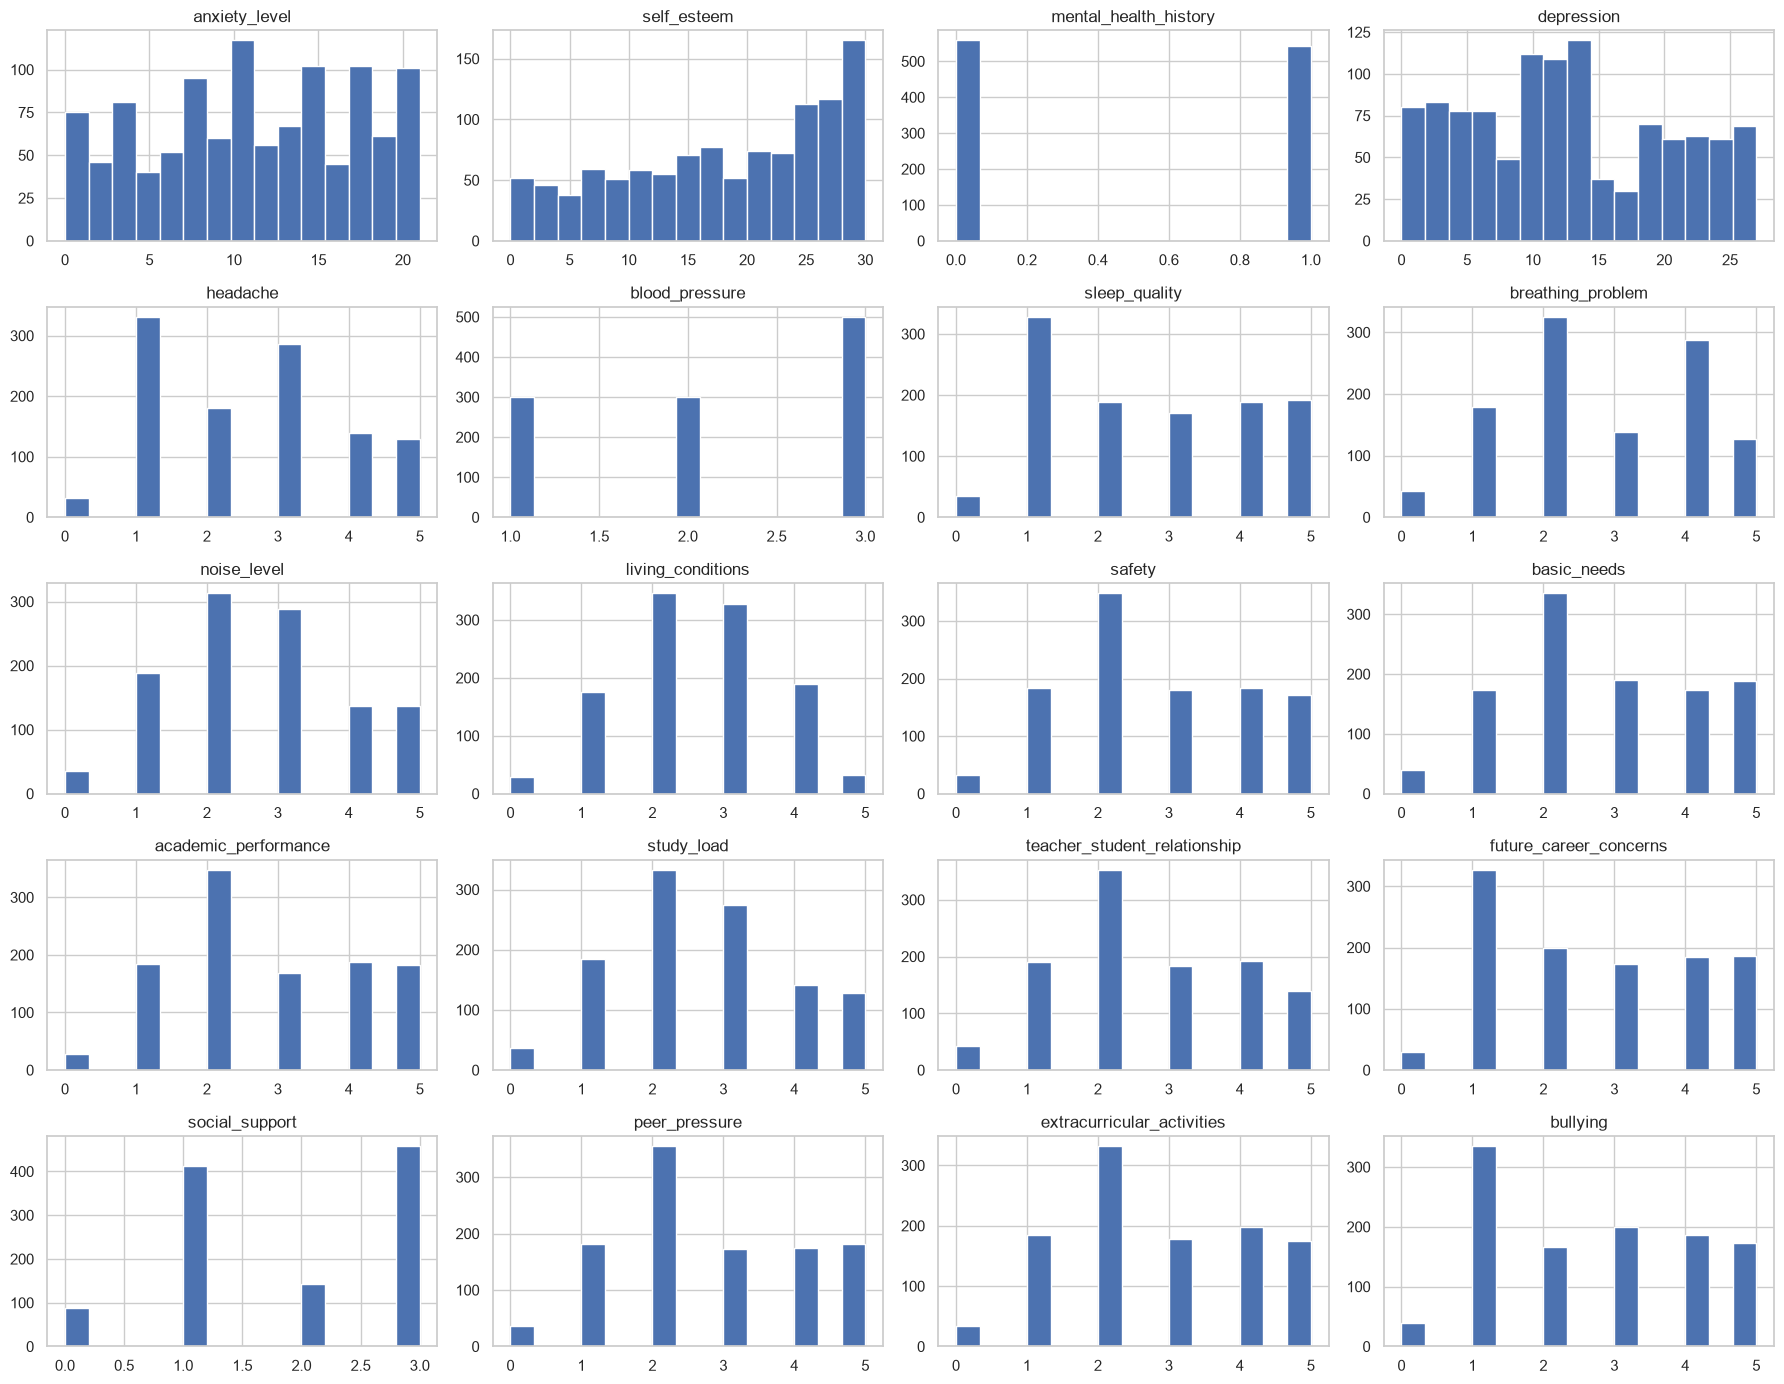

In [8]:
df.drop(columns=["stress_level"]).hist(figsize=(18, 14), bins=15)
plt.tight_layout()
plt.show()

Histogram menunjukkan sebagian besar fitur (misalnya `noise_level`, `safety`, `basic_needs`) terdistribusi cukup merata di seluruh rentang nilainya, sementara beberapa fitur seperti `mental_health_history` bersifat biner. Tidak terlihat pola distribusi yang sangat menceng (skewed) secara ekstrem pada fitur-fitur utama.

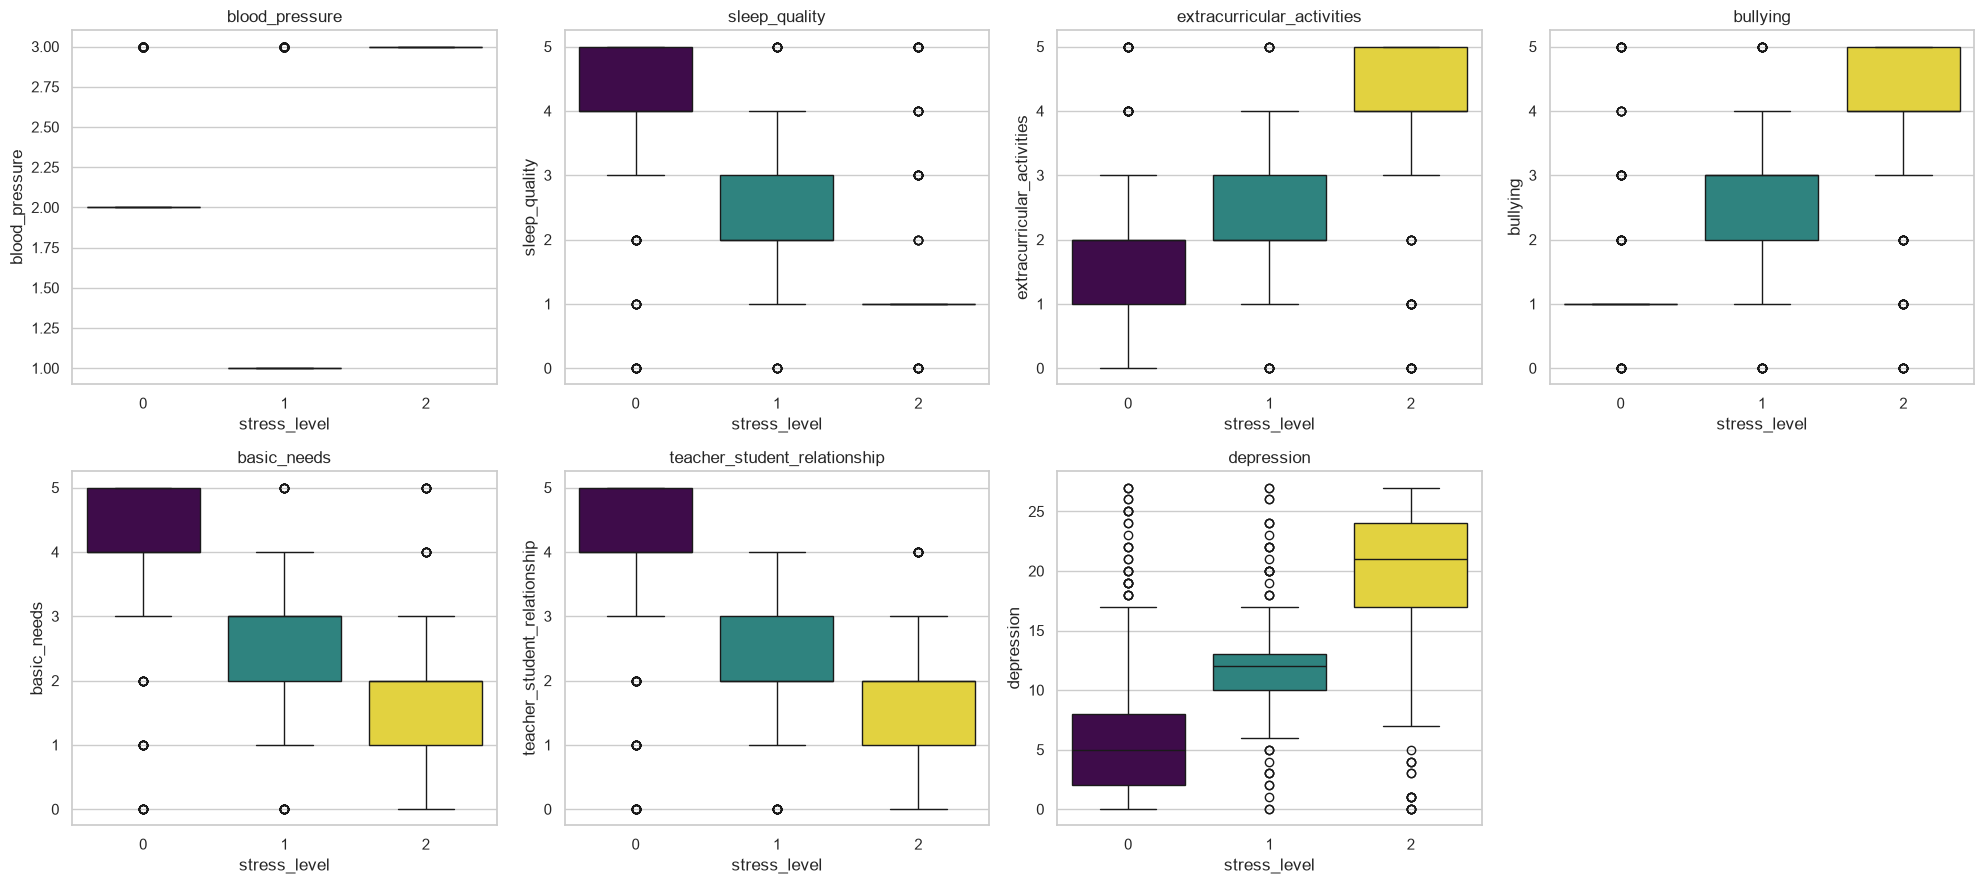

In [9]:
top_features = ["blood_pressure", "sleep_quality", "extracurricular_activities", "bullying", "basic_needs", "teacher_student_relationship", "depression"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, feature in enumerate(top_features):
    sns.boxplot(data=df, x="stress_level", y=feature, ax=axes[i], hue="stress_level", legend=False, palette="viridis")
    axes[i].set_title(feature)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

Boxplot 7 fitur dengan feature importance tertinggi (lihat bagian 8) terhadap `stress_level` memperlihatkan pola yang jelas: mahasiswa dengan `stress_level` tinggi cenderung punya `blood_pressure` lebih tinggi, `sleep_quality` lebih rendah, dan `depression` lebih tinggi dibanding kelompok stres rendah. Ini konsisten dengan intuisi domain bahwa kualitas tidur dan tekanan darah berkaitan erat dengan tingkat stres.

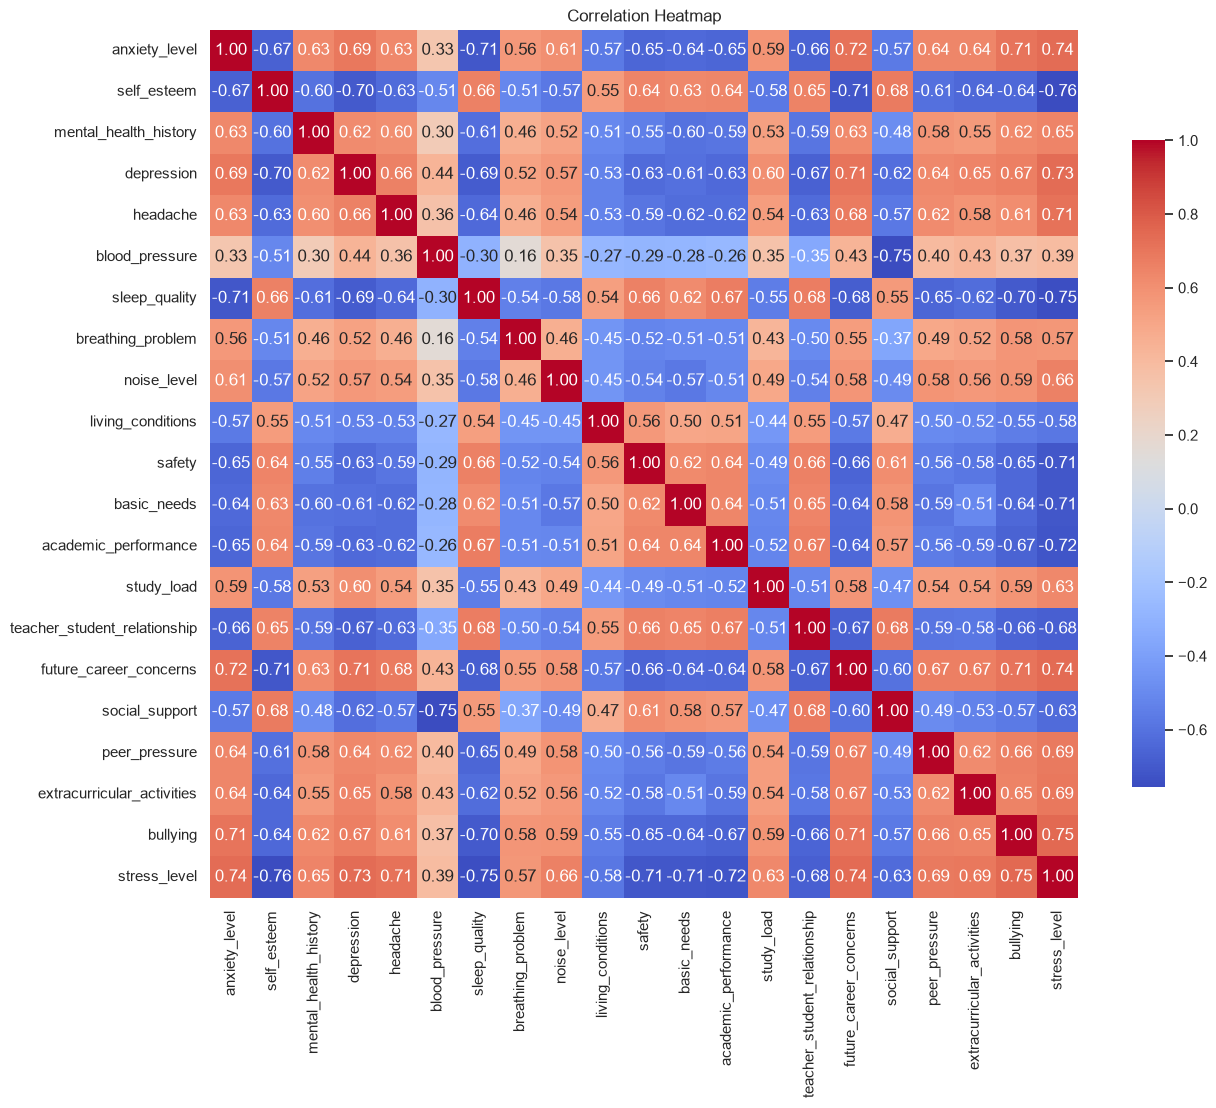

In [10]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlation Heatmap")
plt.show()

Correlation heatmap menunjukkan `stress_level` berkorelasi paling kuat (positif) dengan `anxiety_level`, `depression`, `bullying`, dan `blood_pressure`, serta berkorelasi negatif dengan `self_esteem`, `sleep_quality`, dan `social_support`. Tidak ada tanda multikolinearitas ekstrem antar fitur (korelasi antar fitur pada umumnya moderat), sehingga seluruh fitur tetap layak dipertahankan dalam pemodelan.

## 5. Preprocessing

In [11]:
X = df.drop(columns=["stress_level"])
y = df["stress_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)

Train shape: (880, 20)  Test shape: (220, 20)


Split dilakukan 80:20 secara stratified agar proporsi ketiga kelas `stress_level` tetap terjaga di data train maupun test. Scaling menggunakan `StandardScaler` yang di-fit hanya pada data train untuk menghindari data leakage, lalu diterapkan pada data test.

## 6. Training Model: Logistic Regression dan Random Forest

In [12]:
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("Kedua model selesai dilatih.")

Kedua model selesai dilatih.


Dua algoritma dipilih dengan alasan yang berbeda: **Logistic Regression** sebagai baseline linear yang interpretable dan cocok karena fitur bersifat ordinal yang cenderung berhubungan cukup linear dengan target, sedangkan **Random Forest** untuk menangkap interaksi non-linear antar faktor, lebih robust terhadap fitur yang kurang informatif, dan sekaligus memberikan feature importance.

## 7. Evaluasi Model

=== Logistic Regression ===
Accuracy: 0.8818
              precision    recall  f1-score   support

           0     0.8630    0.8514    0.8571        74
           1     0.9041    0.9167    0.9103        72
           2     0.8784    0.8784    0.8784        74

    accuracy                         0.8818       220
   macro avg     0.8818    0.8821    0.8820       220
weighted avg     0.8816    0.8818    0.8817       220



=== Random Forest ===
Accuracy: 0.8909
              precision    recall  f1-score   support

           0     0.9254    0.8378    0.8794        74
           1     0.8933    0.9306    0.9116        72
           2     0.8590    0.9054    0.8816        74

    accuracy                         0.8909       220
   macro avg     0.8926    0.8913    0.8909       220
weighted avg     0.8926    0.8909    0.8907       220



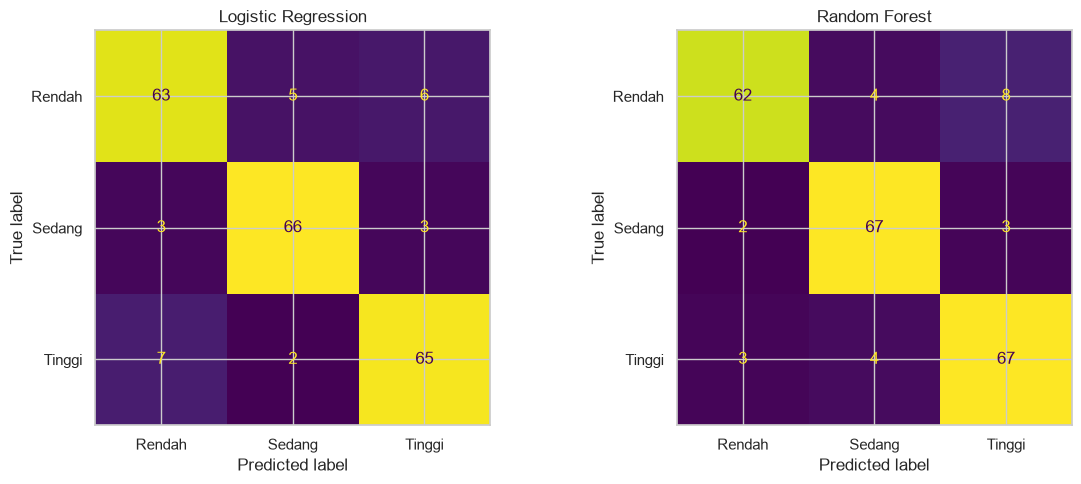

In [13]:
candidates = {
    "Logistic Regression": logreg_model,
    "Random Forest": rf_model,
}

accuracies = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, candidates.items()):
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Rendah", "Sedang", "Tinggi"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [14]:
comparison = pd.DataFrame({"Accuracy": accuracies}).sort_values("Accuracy", ascending=False)
comparison

,Accuracy
Random Forest,0.890909
Logistic Regression,0.881818


**Pemilihan model terbaik:** model dengan akurasi tertinggi pada data test dipilih sebagai model yang dideploy ke aplikasi Gradio. Berdasarkan tabel komparasi di atas, Random Forest secara konsisten sedikit lebih unggul dibanding Logistic Regression pada seluruh metrik (accuracy, precision, recall, F1), sejalan dengan dugaan awal bahwa hubungan antar fitur terhadap tingkat stres tidak sepenuhnya linear.

## 8. Feature Importance (Random Forest)

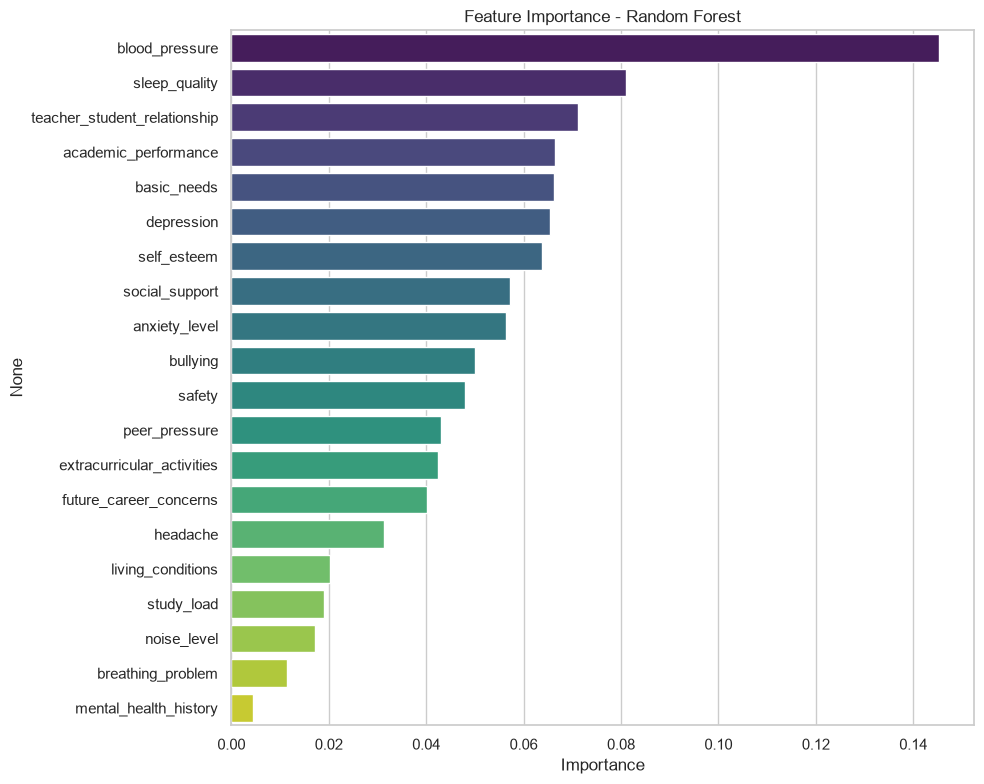

blood_pressure                  0.145205
sleep_quality                   0.080919
teacher_student_relationship    0.071258
academic_performance            0.066403
basic_needs                     0.066138
depression                      0.065374
self_esteem                     0.063838
dtype: float64

In [15]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="viridis", legend=False)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(7)

## 9. Insight dan Kesimpulan

- Tujuh faktor paling berpengaruh terhadap indikasi tingkat stres mahasiswa (berdasarkan feature importance Random Forest) adalah `blood_pressure`, `sleep_quality`, `teacher_student_relationship`, `academic_performance`, `basic_needs`, `depression`, dan `self_esteem`, kombinasi faktor fisiologis, akademik, dan psikologis.
- Kedua model (Logistic Regression dan Random Forest) mencapai akurasi di atas 88% pada data test, menunjukkan bahwa 20 fitur yang tersedia cukup informatif untuk memprediksi tingkat stres.
- Random Forest dipilih sebagai model yang dideploy karena performanya sedikit lebih baik dan mampu menangkap hubungan non-linear antar faktor.
- Rekomendasi: intervensi untuk menurunkan tingkat stres mahasiswa sebaiknya menyasar kualitas tidur, hubungan dosen-mahasiswa, dan pemenuhan kebutuhan dasar, karena faktor-faktor ini termasuk yang paling berpengaruh dan relatif dapat diintervensi lewat kebijakan kampus.
- Hasil prediksi aplikasi ini bersifat indikasi/estimasi awal untuk kebutuhan edukasi, bukan diagnosis klinis, dan tidak menggantikan konsultasi dengan tenaga profesional.

## 10. Simpan Model

In [16]:
models_dir = os.path.join("..", "models")
os.makedirs(models_dir, exist_ok=True)

best_name = comparison.index[0]
best_model = candidates[best_name]

joblib.dump(scaler, os.path.join(models_dir, "scaler.pkl"))
joblib.dump(best_model, os.path.join(models_dir, "supervised_model.pkl"))
importances.head(7).to_csv(os.path.join(models_dir, "importances.txt"))

print(f"Model terbaik ({best_name}) dan scaler berhasil disimpan ke {models_dir}")

Model terbaik (Random Forest) dan scaler berhasil disimpan ke ..\models
